<div style="text-align: center;">
    <a href="https://www.hi-paris.fr/">
        <img border="0" src="https://www.hi-paris.fr/wp-content/uploads/2020/09/logo-hi-paris-retina.png" width="25%"></a>
    <a href="https://www.dataia.eu/">
        <img border="0" src="https://github.com/ramp-kits/template-kit/raw/main/img/DATAIA-h.png" width="70%"></a>
</div>

# FLIP AAV Capsid Optimization Challenge

*Predicting protein fitness from amino acid sequences*

<i> Cécile Luc </i><br/>
<i> Alizée Mesnard </i><br/>
<i> Hamza Boukhriss </i><br/>
<i> Laurian Truong </i><br/>
<i> Nicolas Bieszczad </i><br/>
<i> Nardi Xhepi </i><br/>

## Introduction

### Where does the data come from?

The data comes from the **FLIP** (Fitness Landscape Inference for Proteins) benchmark, specifically the **AAV** (Adeno-Associated Virus) dataset. It was generated through a deep mutational scanning (DMS) experiment that measured the packaging fitness of ~280,000 variants of the AAV2 capsid protein VP1 ([Bryant et al., 2021]()). LIEN A INSÉRER

Each variant is a mutated version of the wild-type AAV2 VP1 protein (~735 amino acids long), and its fitness score reflects how well the capsid packages viral DNA — a critical function for gene therapy delivery.

### What is the task?

Given an amino acid sequence of an AAV capsid variant, **predict its fitness score** (a continuous value). This is a **regression** task evaluated using **Spearman's rank correlation coefficient (ρ)**.

The key challenge is **epistasis** (non-additive mutation interactions): the model is trained on variants with **1–2 mutations** but must generalize to variants with **3 or more mutations**. This means simple additive models will fail — the model must learn how mutations interact.

### Why does it matter?

AAV vectors are the leading platform for **gene therapy** — they deliver therapeutic genes into patients' cells. Engineering better capsids is crucial for:
- **Improving tissue targeting** (e.g., reaching the brain, liver, or muscles)
- **Evading immune responses** that reduce treatment efficacy
- **Increasing packaging efficiency** for larger therapeutic genes

Being able to predict the fitness of unseen multi-mutant capsids would dramatically accelerate the design of next-generation gene therapy vectors, reducing the need for expensive wet-lab experiments.

## Exploratory Data Analysis

Let's explore the dataset to understand its structure and key properties.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None)

# Load the training data
from ingestion_program.ingestion import get_train_data
X_train, y_train = get_train_data("dev_phase/input_data")

print(f"Training set: {X_train.shape[0]} samples")
print(f"Features: {X_train.columns.tolist()}")
print(f"Target: {y_train.columns.tolist()}")
X_train.head(3)

Training set: 31807 samples
Features: ['sequence']
Target: ['target']


,sequence
0,MAADGYLPDWLEDTLSEGIRQWWKLKPGPPPPKPAERHKDDSRGLV...
1,MAADGYLPDWLEDTLSEGIRQWWKLKPGPPPPKPAERHKDDSRGLV...
2,MAADGYLPDWLEDTLSEGIRQWWKLKPGPPPPKPAERHKDDSRGLV...


### Data overview

Each sample is a protein sequence (a string of ~735 amino acid characters) with an associated fitness score.

In [2]:
# Basic statistics on the sequences
seq_lengths = X_train['sequence'].str.len()
print(f"Sequence length — Min: {seq_lengths.min()}, Max: {seq_lengths.max()}, Mean: {seq_lengths.mean():.1f}")
print(f"\nSequence length distribution:")
print(seq_lengths.value_counts().sort_index())

print(f"\nTarget (fitness) statistics:")
print(y_train['target'].describe())

Sequence length — Min: 734, Max: 737, Mean: 735.9

Sequence length distribution:
sequence
734       28
735    10462
736    14856
737     6461
Name: count, dtype: int64

Target (fitness) statistics:
count    31807.000000
mean        -3.354641
std          3.028819
min        -10.217098
25%         -5.597328
50%         -4.441116
75%         -1.312714
max          9.536457
Name: target, dtype: float64


### Fitness distribution

The fitness score is a continuous value. Negative values indicate poor packaging ability, while positive values indicate functional capsids. The wild-type (unmutated) protein has the highest fitness (~9.5).

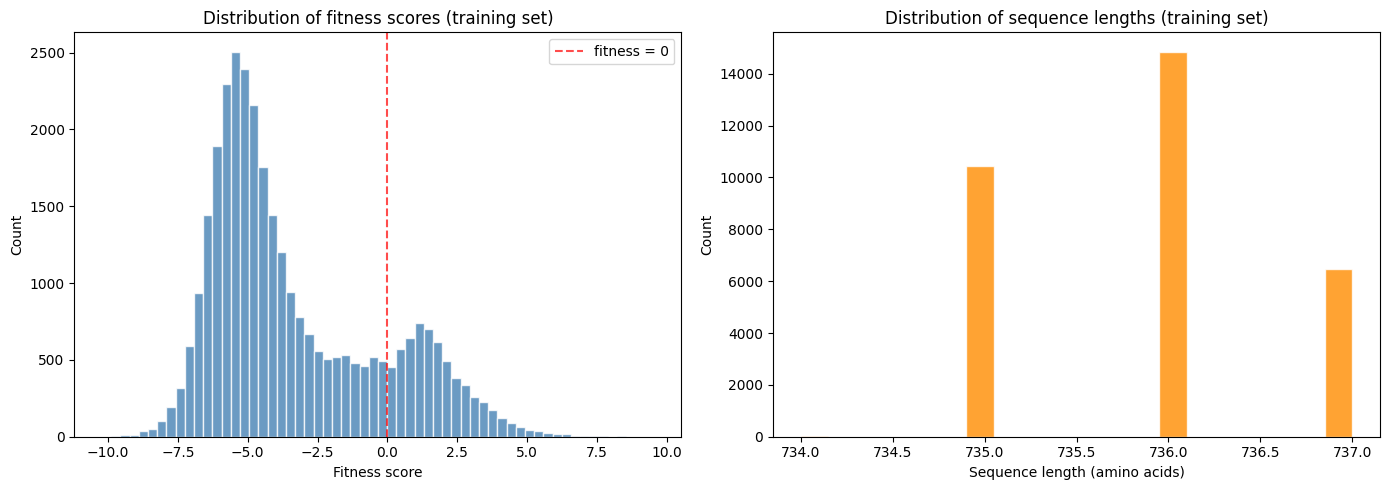

Fraction of functional variants (fitness > 0): 18.9%
Fraction of non-functional variants (fitness < -5): 39.1%


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Fitness distribution
axes[0].hist(y_train['target'], bins=60, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(x=0, color='red', linestyle='--', alpha=0.7, label='fitness = 0')
axes[0].set_xlabel('Fitness score')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of fitness scores (training set)')
axes[0].legend()

# Sequence length distribution
axes[1].hist(seq_lengths, bins=20, color='darkorange', edgecolor='white', alpha=0.8)
axes[1].set_xlabel('Sequence length (amino acids)')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of sequence lengths (training set)')

plt.tight_layout()
plt.show()

print(f"Fraction of functional variants (fitness > 0): {(y_train['target'] > 0).mean():.1%}")
print(f"Fraction of non-functional variants (fitness < -5): {(y_train['target'] < -5).mean():.1%}")

### The epistasis challenge: train on few mutations, test on many

The key difficulty of this challenge is **distribution shift**. The training set contains variants with **1–2 mutations** relative to the wild-type, while the test set contains variants with **3 or more mutations**.

This means the model must learn to generalize from simple mutations to complex combinatorial ones — a phenomenon called **epistasis**, where the effect of combining mutations is not simply the sum of individual effects.

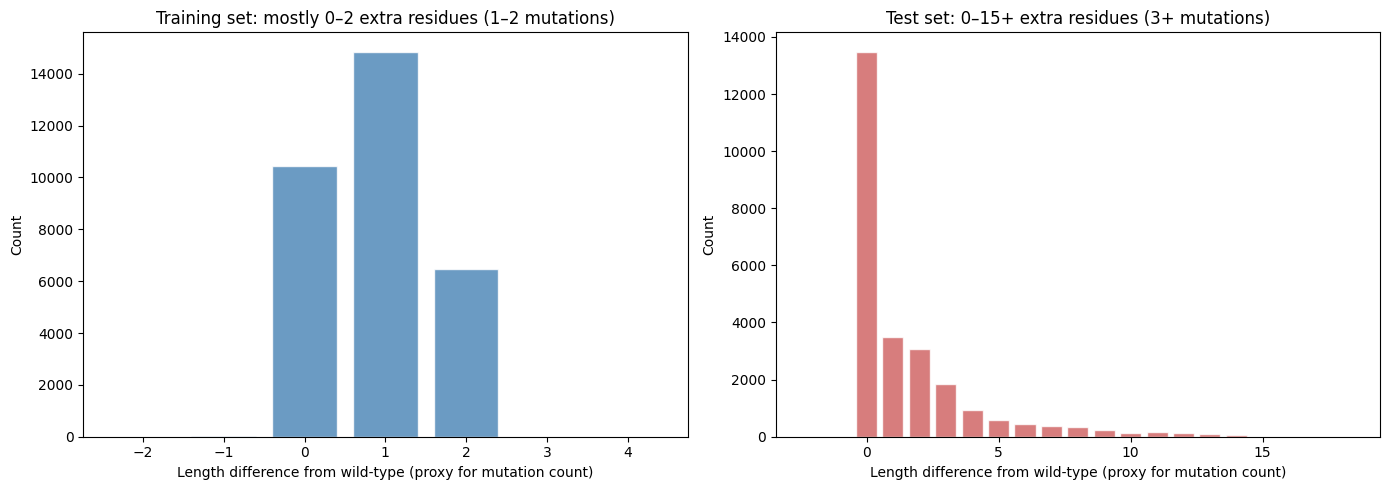

This is the core challenge: the test distribution is very different from training!


In [4]:
# Visualize mutation counts via sequence length difference from wild-type (735 aa)
WT_LENGTH = 735

train_mutations = seq_lengths - WT_LENGTH
test_features = pd.read_csv("dev_phase/input_data/test/test_features.csv")
test_mutations = test_features['sequence'].str.len() - WT_LENGTH

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(train_mutations, bins=range(-2, 6), color='steelblue', edgecolor='white',
             alpha=0.8, align='left', rwidth=0.8)
axes[0].set_xlabel('Length difference from wild-type (proxy for mutation count)')
axes[0].set_ylabel('Count')
axes[0].set_title('Training set: mostly 0–2 extra residues (1–2 mutations)')

axes[1].hist(test_mutations, bins=range(-2, 20), color='indianred', edgecolor='white',
             alpha=0.8, align='left', rwidth=0.8)
axes[1].set_xlabel('Length difference from wild-type (proxy for mutation count)')
axes[1].set_ylabel('Count')
axes[1].set_title('Test set: 0–15+ extra residues (3+ mutations)')

plt.tight_layout()
plt.show()

print("This is the core challenge: the test distribution is very different from training!")

### Amino acid composition

AAV capsid sequences are composed of the 20 standard amino acids. Let's look at the average amino acid composition across training sequences.

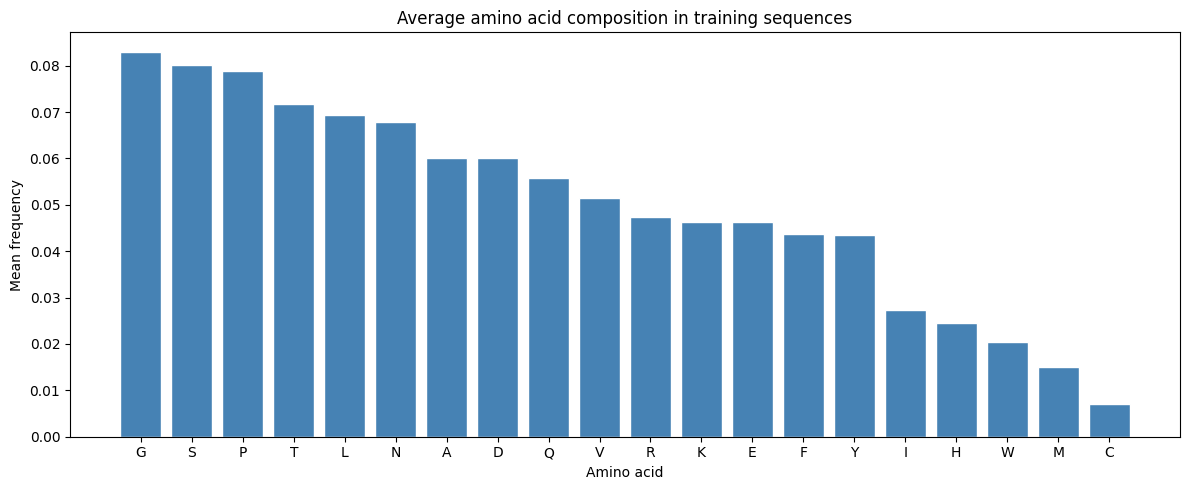

Most frequent amino acids:  G, S, P, T, L
Least frequent amino acids: I, H, W, M, C


In [5]:
from collections import Counter

AMINO_ACIDS = 'ACDEFGHIKLMNPQRSTVWY'

# Compute average amino acid frequency across training sequences
aa_freqs = []
for seq in X_train['sequence'].values[:5000]:  # sample for speed
    counts = Counter(seq)
    total = len(seq)
    aa_freqs.append({aa: counts.get(aa, 0) / total for aa in AMINO_ACIDS})

aa_df = pd.DataFrame(aa_freqs)
mean_freqs = aa_df.mean().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
plt.bar(mean_freqs.index, mean_freqs.values, color='steelblue', edgecolor='white')
plt.xlabel('Amino acid')
plt.ylabel('Mean frequency')
plt.title('Average amino acid composition in training sequences')
plt.tight_layout()
plt.show()

print("Most frequent amino acids: ", ', '.join(mean_freqs.head(5).index))
print("Least frequent amino acids:", ', '.join(mean_freqs.tail(5).index))

## Challenge Evaluation

### Metric: Spearman's Rank Correlation (ρ)

We use **Spearman's rank correlation** to evaluate predictions. In protein engineering, **ranking variants correctly matters more than predicting exact fitness values**. A researcher wants to know *which* variants are the best, not necessarily by how much.

$$\rho = 1 - \frac{6 \sum d_i^2}{n(n^2 - 1)}$$

where $d_i$ is the difference in ranks between predicted and true fitness for variant $i$.

| Score | Interpretation |
|-------|----------------|
| ρ = 1.0 | Perfect ranking |
| ρ ≥ 0.5 | Good correlation |
| ρ = 0.0 | Random ranking |
| ρ < 0.0 | Anti-correlated |

### Evaluation strategy

The test data is split into two sets:
- **Public test** (50%): Spearman correlation is shown on the leaderboard during the competition.
- **Private test** (50%): Used for the final ranking, revealed only at the end.

Both test sets contain variants with **3+ mutations** (not seen during training), so the model must generalize beyond simple single/double mutants.

### Data split summary

| Split | Samples | Mutations | Purpose |
|-------|---------|-----------|---------|
| Train | 31,807 | 1–2 | Model training |
| Public test | 25,388 | 3+ | Leaderboard score |
| Private test | 25,388 | 3+ | Final ranking |

## Submission Format

Participants must submit a Python file named `submission.py` containing a `get_model()` function that returns a scikit-learn compatible model.

### Requirements

Your model must implement:
- **`fit(X, y)`**: Train on a DataFrame `X` with a `sequence` column and a target `y` (fitness scores).
- **`predict(X)`**: Return predicted fitness scores for new sequences.

### Example structure

```python
from sklearn.base import BaseEstimator, RegressorMixin

class MyModel(BaseEstimator, RegressorMixin):
    def fit(self, X, y):
        # X is a DataFrame with a 'sequence' column
        # y contains the fitness scores
        ...
        return self
    
    def predict(self, X):
        # Return predicted fitness scores
        ...
        return predictions

def get_model():
    return MyModel()
```

## Baseline Solution

Below is the baseline submission. It extracts features from protein sequences (amino acid composition + k-mer frequencies) and uses Ridge regression for prediction.

In [6]:
# %load solution/submission.py
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
import numpy as np
from collections import Counter

AMINO_ACIDS = 'ACDEFGHIKLMNPQRSTVWY'

class SequenceFitnessRegressor(BaseEstimator, RegressorMixin):
    """
    Baseline fitness prediction model.
    
    Features extracted from each sequence:
    - Amino acid composition (frequency of each of the 20 AAs)
    - 2-mer and 3-mer frequencies (short subsequence patterns)
    - Sequence length
    
    Uses Ridge regression for robust high-dimensional fitting.
    """
    def __init__(self, alpha=10.0):
        self.alpha = alpha
        self.model = Ridge(alpha=alpha)
        self.scaler = StandardScaler()
        self.kmer2_vocab = None
        self.kmer3_vocab = None

    def _get_aa_composition(self, sequence):
        counts = Counter(sequence)
        total = len(sequence)
        return np.array([counts.get(aa, 0) / total for aa in AMINO_ACIDS])

    def _get_kmer_counts(self, sequence, k, vocab):
        kmers = [sequence[i:i+k] for i in range(len(sequence) - k + 1)]
        counts = Counter(kmers)
        total = len(kmers) if kmers else 1
        return np.array([counts.get(kmer, 0) / total for kmer in vocab])

    def _build_kmer_vocab(self, sequences, k):
        all_kmers = set()
        for seq in sequences:
            for i in range(len(seq) - k + 1):
                all_kmers.add(seq[i:i+k])
        return sorted(all_kmers)

    def _sequence_to_features(self, sequence):
        features = []
        features.extend(self._get_aa_composition(sequence))       # 20 features
        features.extend(self._get_kmer_counts(sequence, 2, self.kmer2_vocab))  # ~400 features
        features.extend(self._get_kmer_counts(sequence, 3, self.kmer3_vocab))  # ~8000 features
        features.append(len(sequence) / 735.0)                    # 1 feature (normalized length)
        return np.array(features)

    def fit(self, X, y):
        import pandas as pd
        sequences = X['sequence'].values
        if isinstance(y, pd.DataFrame):
            y = y.values.ravel()
        elif hasattr(y, 'values'):
            y = y.values.ravel()

        self.kmer2_vocab = self._build_kmer_vocab(sequences, 2)
        self.kmer3_vocab = self._build_kmer_vocab(sequences, 3)

        X_features = np.array([self._sequence_to_features(seq) for seq in sequences])
        X_scaled = self.scaler.fit_transform(X_features)
        self.model.fit(X_scaled, y)
        return self

    def predict(self, X):
        sequences = X['sequence'].values
        X_features = np.array([self._sequence_to_features(seq) for seq in sequences])
        X_scaled = self.scaler.transform(X_features)
        return self.model.predict(X_scaled)


def get_model():
    """Return the baseline model for the FLIP AAV fitness prediction challenge."""
    return SequenceFitnessRegressor(alpha=10.0)

## Local Testing Pipeline

Let's train the baseline model and evaluate it locally to see how it performs. This is exactly the pipeline that runs on Codabench when you submit.

In [7]:
from scipy.stats import spearmanr
import time

# 1. Load training data
X_train, y_train = get_train_data("dev_phase/input_data")

# 2. Train the baseline model
model = get_model()
print("Training the baseline model...")
start = time.time()
model.fit(X_train, y_train)
train_time = time.time() - start
print(f"Training completed in {train_time:.1f}s")

# 3. Predict on test set
X_test = pd.read_csv("dev_phase/input_data/test/test_features.csv")
y_test_true = pd.read_csv("dev_phase/reference_data/test_labels.csv")

print("\nPredicting on test set...")
start = time.time()
y_test_pred = model.predict(X_test)
test_time = time.time() - start
print(f"Prediction completed in {test_time:.1f}s")

# 4. Evaluate with Spearman correlation
corr, pval = spearmanr(y_test_pred, y_test_true['target'].values)
print(f"\n{'='*40}")
print(f"Spearman correlation on public test: {corr:.4f}")
print(f"{'='*40}")

Training the baseline model...
Training completed in 24.8s

Predicting on test set...
Training completed in 24.8s

Predicting on test set...
Prediction completed in 15.0s

Spearman correlation on public test: 0.4206
Prediction completed in 15.0s

Spearman correlation on public test: 0.4206


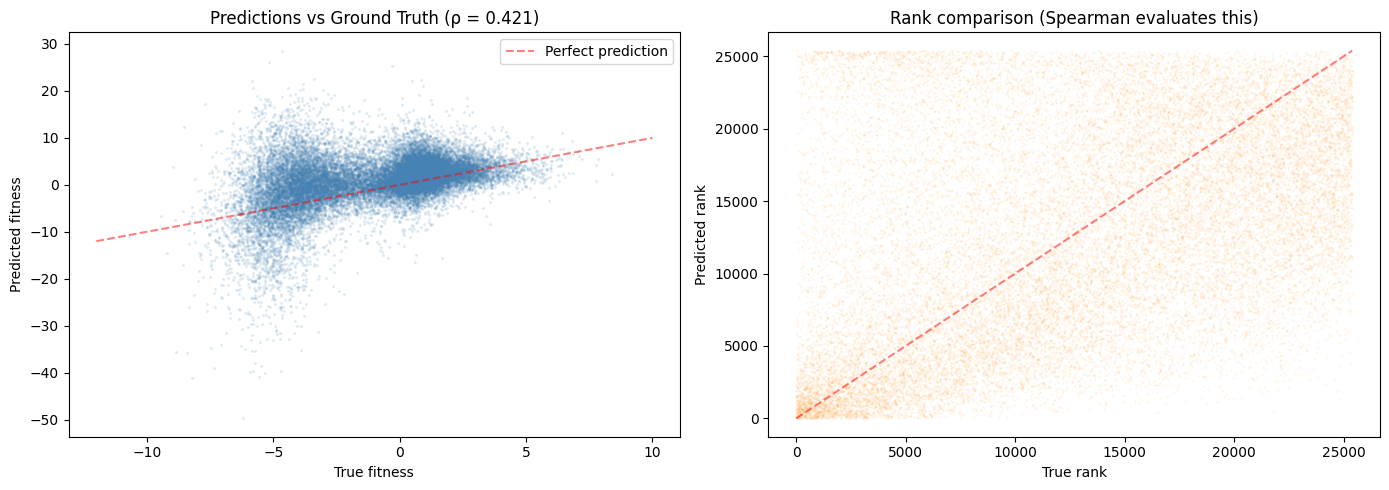

In [8]:
# Visualize predictions vs ground truth
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
axes[0].scatter(y_test_true['target'].values, y_test_pred, alpha=0.1, s=2, color='steelblue')
axes[0].plot([-12, 10], [-12, 10], 'r--', alpha=0.5, label='Perfect prediction')
axes[0].set_xlabel('True fitness')
axes[0].set_ylabel('Predicted fitness')
axes[0].set_title(f'Predictions vs Ground Truth (ρ = {corr:.3f})')
axes[0].legend()

# Rank comparison
true_ranks = y_test_true['target'].rank().values
pred_ranks = pd.Series(y_test_pred).rank().values
axes[1].scatter(true_ranks, pred_ranks, alpha=0.05, s=1, color='darkorange')
axes[1].plot([0, len(true_ranks)], [0, len(true_ranks)], 'r--', alpha=0.5)
axes[1].set_xlabel('True rank')
axes[1].set_ylabel('Predicted rank')
axes[1].set_title('Rank comparison (Spearman evaluates this)')

plt.tight_layout()
plt.show()

## Submission on Codabench

To submit your solution on the [Codabench platform](https://www.codabench.org/):

1. **Create your `submission.py` file** with a `get_model()` function (see format above).
2. **Zip it**: `zip submission.zip submission.py`
3. **Upload** the zip file on the competition page.

The platform will:
- Run the ingestion program: load your model, train it, and generate predictions
- Run the scoring program: compute Spearman correlation on public and private test sets
- Display your public test score on the leaderboard

### Tips for improvement

- **Feature engineering**: Try positional encoding, physicochemical properties of amino acids, or mutation-specific features.
- **Non-linear models**: Gradient boosting (XGBoost, LightGBM) or neural networks may capture epistatic interactions better than linear models.
- **Protein language models**: Pre-trained models like ESM-2 or ProtBERT can provide powerful sequence embeddings.
- **Ensemble methods**: Combining multiple models often improves robustness.

Good luck! 🧬